In [5]:
import pandas as pd

# Load the data
df = pd.read_csv('../data/raw/SPY_daily_yahoo_raw.csv', skiprows=[0,1,2], header=None, names=['Date','Adj Close','Close','High','Low','Open','Volume'], index_col=0, parse_dates=True, dtype={'Adj Close': float, 'Close': float, 'High': float, 'Low': float, 'Open': float, 'Volume': int})

# Compute 1-time-index linear increments
df['delta_P'] = df['Adj Close'].diff()

df = df.copy()
df['t'] = range(1, len(df) + 1)

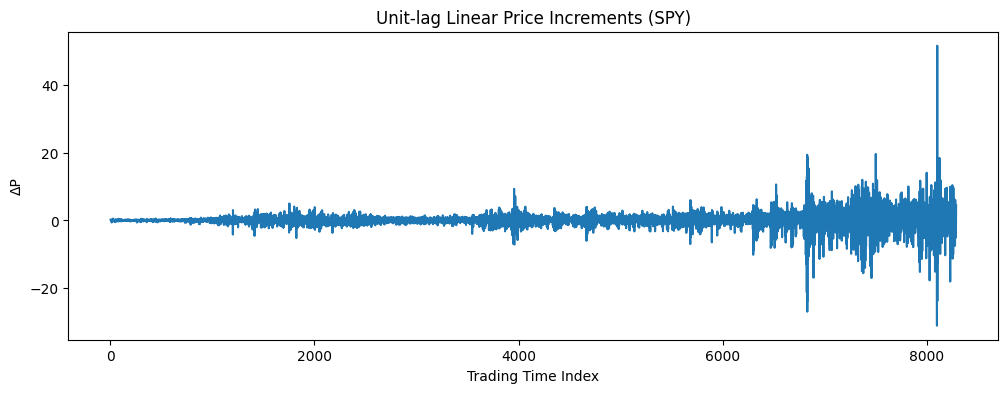

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df['t'], df['delta_P'])
plt.title('Unit-lag Linear Price Increments (SPY)')
plt.xlabel('Trading Time Index')
plt.ylabel('ΔP')
plt.show()


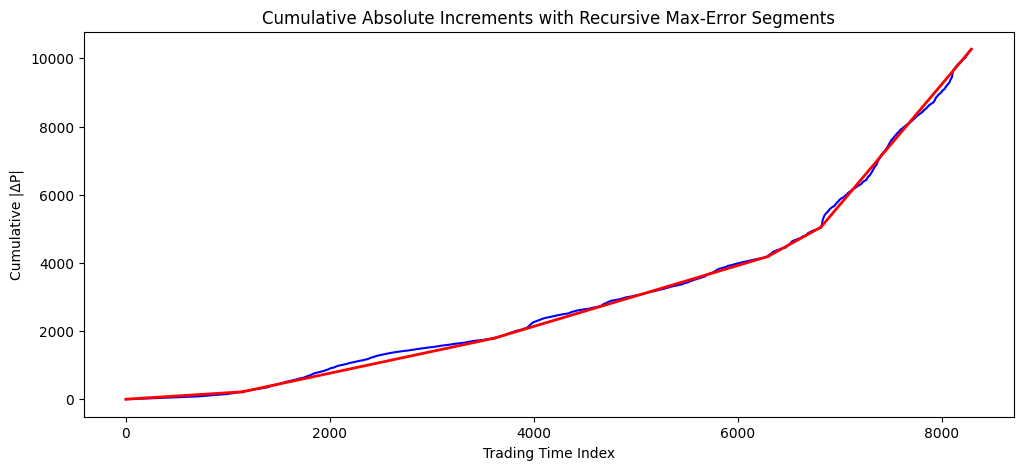

Segment 1: Start=0, End=1142, Slope=0.1902, Points=1143
Segment 2: Start=1142, End=3612, Slope=0.6373, Points=2471
Segment 3: Start=3612, End=6292, Slope=0.8934, Points=2681
Segment 4: Start=6292, End=6812, Slope=1.6523, Points=521
Segment 5: Start=6812, End=8288, Slope=3.5387, Points=1477


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Cumulative absolute increments
cum_abs = np.cumsum(np.abs(df['delta_P'].dropna().values))
t_indices = np.arange(len(cum_abs))

# Parameters
max_segments = 5   # maximum number of segments allowed
threshold = 0      # set 0 to always split until max_segments

# Initial segment: full series
segments = [(0, len(cum_abs)-1)]
lines = []

# Recursive splitting based on max error
while len(segments) < max_segments:
    # Find segment with maximum deviation
    max_err = -1
    seg_to_split = None
    split_idx = None

    for seg in segments:
        start, end = seg
        # line connecting endpoints
        line = cum_abs[start] + (cum_abs[end] - cum_abs[start]) / (end - start) * (t_indices[start:end+1] - start)
        # absolute error
        error = np.abs(cum_abs[start:end+1] - line)
        local_max_idx = np.argmax(error)
        local_max_err = error[local_max_idx]

        if local_max_err > max_err:
            max_err = local_max_err
            seg_to_split = seg
            split_idx = start + local_max_idx

    if max_err <= threshold:
        break  # stop if deviation below threshold

    # split the segment at split_idx
    segments.remove(seg_to_split)
    start, end = seg_to_split
    segments.append((start, split_idx))
    segments.append((split_idx, end))

# Sort segments by start index
segments = sorted(segments, key=lambda x: x[0])

# Prepare lines for plotting
lines = []
for seg in segments:
    start, end = seg
    line = cum_abs[start] + (cum_abs[end] - cum_abs[start]) / (end - start) * (t_indices[start:end+1] - start)
    lines.append((t_indices[start:end+1], line))

# Plot cumulative absolute increments with lines
plt.figure(figsize=(12,5))
plt.plot(t_indices, cum_abs, label='Cumulative |ΔP|', color='blue')
for l in lines:
    plt.plot(l[0], l[1], color='red', linewidth=2)
plt.title('Cumulative Absolute Increments with Recursive Max-Error Segments')
plt.xlabel('Trading Time Index')
plt.ylabel('Cumulative |ΔP|')
plt.show()

# Print segment info
for i, seg in enumerate(segments):
    start, end = seg
    slope = (cum_abs[end] - cum_abs[start]) / (end - start)
    print(f"Segment {i+1}: Start={start}, End={end}, Slope={slope:.4f}, Points={end-start+1}")


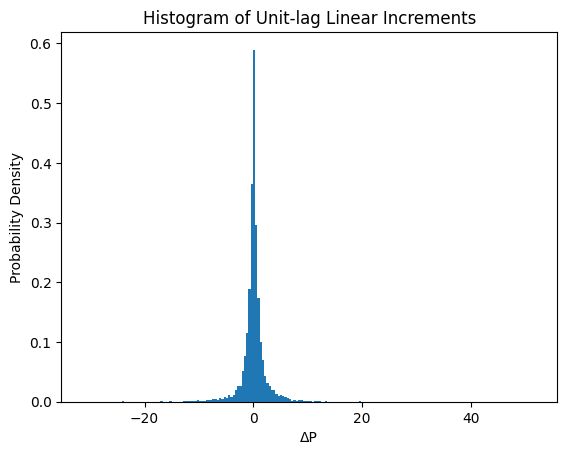

In [4]:
plt.figure()
plt.hist(df['delta_P'].dropna(), bins=200, density=True)
plt.title('Histogram of Unit-lag Linear Increments')
plt.xlabel('ΔP')
plt.ylabel('Probability Density')
plt.show()
# Plot the linear increments